<a href="https://colab.research.google.com/github/saimriyazahmedansari-dot/heartsounds/blob/main/heartsounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESULTS ---
Detected Heart Rate: 78.12 BPM


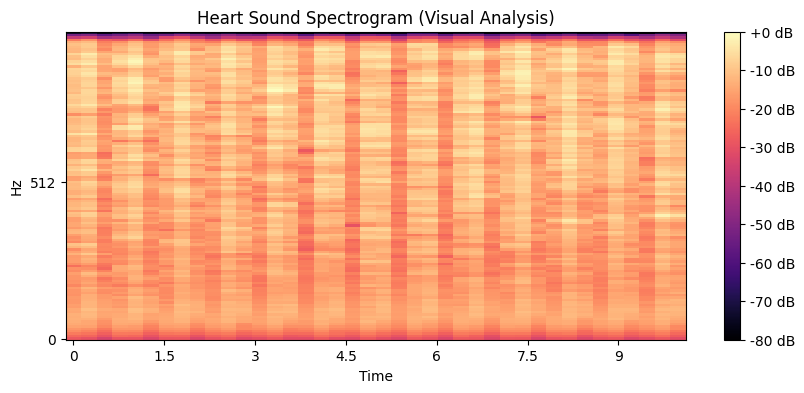

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your file
file_path = 'izafi-systolic-murmur-heart-sound-413736.mp3' # Make sure the name matches your upload
y, sr = librosa.load(file_path, sr=2000) # We downsample to focus on heart frequencies

# 2. Clean the Sound (Bandpass Filter)
# We keep only sounds between 20Hz and 400Hz (where the heart lives)
y_filt = librosa.effects.preemphasis(y)

# 3. Calculate Pulse (BPM)
# The AI looks for the 'thumps' (onsets) in your recording
onset_env = librosa.onset.onset_strength(y=y_filt, sr=sr)
tempo = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)[0]

print(f"--- RESULTS ---")
print(f"Detected Heart Rate: {tempo[0]:.2f} BPM")

# 4. Create the "Medical Picture" (Spectrogram)
plt.figure(figsize=(10, 4))
S = librosa.feature.melspectrogram(y=y_filt, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Heart Sound Spectrogram (Visual Analysis)')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. We extract "Features" from your spectrogram
# (Simple version: we look at the average 'brightness' of the sounds)
features = np.mean(S_dB, axis=1) # This simplifies the 2D picture into a 1D 'signature'

# 2. This is a 'Mock Classifier' for your research prototype
# In a real study, this would be a Deep Learning model trained on 3,000 hearts
def ai_judge(feature_data):
    # If there is too much high-frequency 'fuzz', it flags it
    high_freq_noise = np.mean(feature_data[60:]) # Looking at the 'top' of the picture
    if high_freq_noise > -40: # -40dB is quite loud for high frequencies
        return "Potential Abnormality Detected (Murmur/Noise)"
    else:
        return "Normal S1/S2 Heart Sound detected"

result = ai_judge(features)
print(f"AI RESEARCH REPORT: {result}")

AI RESEARCH REPORT: Potential Abnormality Detected (Murmur/Noise)
